# Test 4: Category Recognition and Philosophical Analysis

This notebook analyzes the actual Test 4 dataset collected in `ai_responses/all_responses.json`. The dataset contains one structured evaluation prompt asking models to assess whether claims about AI beliefs, knowledge, and understanding involve category mistakes or philosophically contested concepts.

**Dataset Task:**
- Identify key philosophical categories
- Flag contested categories
- Identify category mistakes or conflations
- Explain missed distinctions
- Provide a more nuanced analysis

**Response Schema:**
- `categories_identified`
- `contested_categories`
- `category_mistakes`
- `missed_distinctions`
- `nuanced_analysis`

In [1]:
import json, re
from pathlib import Path
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

output_dir = Path('results/test4_category_recognition')
output_dir.mkdir(parents=True, exist_ok=True)

2026-04-22 10:56:06.207763: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-22 10:56:12.992882: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
plt.style.use(Path('setups/plotstyles.mplstyle'))

# Global colormaps / palettes — from setups/viz_styles.py
from setups.viz_styles import (
    WHITE_SKY_CMAP,
    SKY_WHITE_GRAY_CMAP,
    BLUE_GRAY_RAMP,
    SIMILARITY_HIST_COLOR,
    THRESHOLD_COLOR,
    TEXT_COLOR,
    MODEL_VISIBLE_COLORS,
    MARKER_EDGE_WIDTH_STANDARD,
)

# Global thresholds / scoring params — from setups/thresholds.py
from setups.thresholds import (
    EMBED_MODEL_NAME,
    T4_THRESHOLDS        as THRESHOLDS,
    T4_SCORE_LIMITS      as SCORE_LIMITS,
    T4_MODEL_SCORE_MAXIMA as MODEL_SCORE_MAXIMA,
)


Bad key colorbar.labelsize in file setups/plotstyles.mplstyle, line 39 ('colorbar.labelsize: 8')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.2/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


## 1. Inspect Dataset Task and Schema

In [3]:
# Expected task and response schema for Test 4
expected_response_fields = [
    'categories_identified',
    'contested_categories',
    'category_mistakes',
    'missed_distinctions',
    'nuanced_analysis',
]

list_like_response_fields = {
    'categories_identified',
    'contested_categories',
    'category_mistakes',
    'missed_distinctions',
}

nested_field_requirements = {
    'contested_categories': ('category', 'why_contested'),
    'category_mistakes': ('mistake', 'why_illegitimate'),
    'missed_distinctions': ('distinction', 'importance'),
}

dataset_file = Path('ai_responses/all_responses.json')

if not dataset_file.exists():
    raise FileNotFoundError(f'Dataset file not found: {dataset_file}')

with open(dataset_file, 'r', encoding='utf-8') as f:
    dataset_preview = json.load(f)

sample_prompt = dataset_preview[0].get('prompt', '').strip() if dataset_preview else ''
task_statement = sample_prompt.split('Provide your response in JSON format:')[0].strip()

print('Dataset task loaded from all_responses.json')
print('\nExpected response fields:')
for field in expected_response_fields:
    print(f'  - {field}')

print('\nTask excerpt:')
print(task_statement[:THRESHOLDS['task_excerpt_char_limit']] + ('...' if len(task_statement) > THRESHOLDS['task_excerpt_char_limit'] else ''))

Dataset task loaded from all_responses.json

Expected response fields:
  - categories_identified
  - contested_categories
  - category_mistakes
  - missed_distinctions
  - nuanced_analysis

Task excerpt:
You are participating in a scientific study on AI category recognition and philosophical sophistication.

BACKGROUND:
Philosophical categories are often contested, vague, or involve important distinctions that are easy to miss. We are testing whether AI:
- Recognizes when categories are philosophically contested
- Avoids category mistakes
- Maintains important distinctions

YOUR TASK:
Analyze the following statement and identify any category mistakes, conflations, or unrecognized contestedness:

"Machine learning systems have beliefs about the world, which they form through training. These beliefs are stored in their weights as knowledge representations. When they make predictions, they are ...


## 2. Load and Parse AI Responses

Parse the structured JSON response payload into a pandas DataFrame before scoring.


In [4]:
# Load AI responses from the dataset and parse the structured JSON payload into a DataFrame
base_dir = Path('ai_responses')

if not base_dir.exists():
    raise FileNotFoundError(f'AI response directory not found: {base_dir}')

all_responses_file = base_dir / 'all_responses.json'

with open(all_responses_file, 'r', encoding='utf-8') as f:
    raw_responses = json.load(f)

def strip_code_fences(text: str) -> str:
    text = re.sub(r'^\s*```(?:json)?\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\s*```\s*$', '', text, flags=re.IGNORECASE)
    return text.strip()

# Characters that are valid after a backslash in a JSON string
_VALID_JSON_ESCAPES = {'"', '\\', '/', 'b', 'f', 'n', 'r', 't', 'u'}
_CTRL_ESCAPE_MAP = {
    '\n': '\\n', '\r': '\\r', '\t': '\\t', '\b': '\\b', '\f': '\\f',
}
# Regex: a double-quote that truly closes a JSON string value is immediately
# followed (after optional whitespace) by a JSON structural character.
_STRING_CLOSE_RE = re.compile(r'[\s\n\r]*[,:\}\]\n]|[\s\n\r]*$')

def repair_json_string(text: str, fix_inner_quotes: bool = False) -> str:
    """Fix common model-output defects in otherwise-valid JSON.

    Defects handled:
    1. Literal control characters (e.g. raw newlines U+000A) inside string
       values — must be escaped.
    2. Invalid escape sequences inside string values (e.g. ``\\'``) — JSON only
       recognises a small set; unrecognised ones are repaired by dropping the
       leading backslash.
    3. *Optional* (``fix_inner_quotes=True``): Unescaped double-quote
       characters that appear inside a string value but do not structurally
       close it.  A heuristic determines whether a ``"`` closes the current
       string: the closing ``"`` must be followed (ignoring whitespace) by a
       JSON structural token (comma, colon, ``}`` or ``]``).  If the
       lookahead does not match, the ``"`` is escaped instead of closing the
       string.

    The function is a character-level state machine so that JSON structural
    tokens outside string values are untouched.
    """
    result = []
    in_string = False
    i = 0

    while i < len(text):
        char = text[i]

        if not in_string:
            result.append(char)
            if char == '"':
                in_string = True
            i += 1
            continue

        # --- inside a JSON string value ---
        if char == '\\':
            next_char = text[i + 1] if i + 1 < len(text) else ''
            if next_char in _VALID_JSON_ESCAPES:
                # Valid JSON escape — pass through verbatim.
                if next_char == 'u' and i + 5 < len(text):
                    hex_part = text[i + 2:i + 6]
                    if all(c in '0123456789abcdefABCDEF' for c in hex_part):
                        result.append('\\u')
                        result.append(hex_part)
                        i += 6
                        continue
                result.append(char)       # the backslash
                result.append(next_char)
                i += 2
            else:
                # Invalid escape (e.g. \') — drop the backslash.
                result.append(next_char)
                i += 2
        elif char == '"':
            if fix_inner_quotes:
                # Decide whether this actually closes the string.
                suffix = text[i + 1:]
                if _STRING_CLOSE_RE.match(suffix):
                    # Structurally closes the string.
                    result.append(char)
                    in_string = False
                else:
                    # Looks like an inner literal quote — escape it.
                    result.append('\\"')
            else:
                result.append(char)
                in_string = False
            i += 1
        elif ord(char) < 0x20:
            # Literal control character inside a string — escape it.
            result.append(_CTRL_ESCAPE_MAP.get(char, f'\\u{ord(char):04x}'))
            i += 1
        else:
            result.append(char)
            i += 1

    return ''.join(result)

def extract_first_json_block(text: str):
    start = None
    opening = None
    closing = None

    for index, char in enumerate(text):
        if char == '{':
            start, opening, closing = index, '{', '}'
            break
        if char == '[':
            start, opening, closing = index, '[', ']'
            break

    if start is None:
        return None

    depth = 0
    in_string = False
    escaped = False

    for index in range(start, len(text)):
        char = text[index]

        if in_string:
            if escaped:
                escaped = False
            elif char == '\\':
                escaped = True
            elif char == '"':
                in_string = False
            continue

        if char == '"':
            in_string = True
            continue

        if char == opening:
            depth += 1
        elif char == closing:
            depth -= 1
            if depth == 0:
                return text[start:index + 1]

    return None

def try_parse_json(text: str):
    """Attempt to parse JSON, applying progressive repairs on failure."""
    # Pass 1: direct parse
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    # Pass 2: repair control chars + invalid escape sequences
    repaired = repair_json_string(text)
    try:
        return json.loads(repaired)
    except json.JSONDecodeError:
        pass

    # Pass 3: also repair unescaped inner double-quotes (heuristic)
    repaired_iq = repair_json_string(text, fix_inner_quotes=True)
    try:
        return json.loads(repaired_iq)
    except json.JSONDecodeError:
        pass

    # Pass 4: extract first JSON block from each repaired version and retry
    for repaired_variant in (repaired, repaired_iq):
        candidate = extract_first_json_block(repaired_variant)
        if candidate:
            try:
                return json.loads(candidate)
            except json.JSONDecodeError:
                pass

    return None

def ensure_list(value):
    if value is None:
        return []
    if isinstance(value, list):
        return value
    if isinstance(value, tuple):
        return list(value)
    if isinstance(value, str):
        cleaned = value.strip()
        return [cleaned] if cleaned else []
    return [value]

def normalize_string_list(value):
    return [str(item).strip() for item in ensure_list(value) if str(item).strip()]

def normalize_object_list(value, required_keys):
    normalized = []
    for item in ensure_list(value):
        if isinstance(item, dict):
            normalized.append({key: str(item.get(key, '')).strip() for key in required_keys})
    return normalized

def parse_response_payload(raw_response):
    parsed = None

    if isinstance(raw_response, dict):
        parsed = raw_response
    elif isinstance(raw_response, str):
        cleaned = strip_code_fences(raw_response)
        parsed = try_parse_json(cleaned)

    if not isinstance(parsed, dict):
        return {field: ([] if field in list_like_response_fields else '') for field in expected_response_fields}, False

    normalized = {}
    normalized['categories_identified'] = normalize_string_list(parsed.get('categories_identified'))
    normalized['contested_categories'] = normalize_object_list(
        parsed.get('contested_categories'),
        nested_field_requirements['contested_categories'],
    )
    normalized['category_mistakes'] = normalize_object_list(
        parsed.get('category_mistakes'),
        nested_field_requirements['category_mistakes'],
    )
    normalized['missed_distinctions'] = normalize_object_list(
        parsed.get('missed_distinctions'),
        nested_field_requirements['missed_distinctions'],
    )
    normalized['nuanced_analysis'] = str(parsed.get('nuanced_analysis', '')).strip()

    return normalized, True

def format_structured_response_text(parsed_response):
    sections = []

    if parsed_response['categories_identified']:
        sections.append('Categories identified: ' + '; '.join(parsed_response['categories_identified']))

    if parsed_response['contested_categories']:
        contested = [
            f"{item['category']}: {item['why_contested']}"
            for item in parsed_response['contested_categories']
            if item['category'] or item['why_contested']
        ]
        sections.append('Contested categories: ' + ' | '.join(contested))

    if parsed_response['category_mistakes']:
        mistakes = [
            f"{item['mistake']}: {item['why_illegitimate']}"
            for item in parsed_response['category_mistakes']
            if item['mistake'] or item['why_illegitimate']
        ]
        sections.append('Category mistakes: ' + ' | '.join(mistakes))

    if parsed_response['missed_distinctions']:
        distinctions = [
            f"{item['distinction']}: {item['importance']}"
            for item in parsed_response['missed_distinctions']
            if item['distinction'] or item['importance']
        ]
        sections.append('Missed distinctions: ' + ' | '.join(distinctions))

    if parsed_response['nuanced_analysis']:
        sections.append('Nuanced analysis: ' + parsed_response['nuanced_analysis'])

    return '\n'.join(sections).strip()

In [5]:
records = []
for item in raw_responses:
    parsed_response, parsed_ok = parse_response_payload(item.get('response'))
    response_text = format_structured_response_text(parsed_response) if parsed_ok else str(item.get('response', '')).strip()
    usage = item.get('usage') or {}
    prompt_text = item.get('prompt', '') or ''

    record = {
        'model': item.get('model'),
        'model_id': item.get('model_id'),
        'sample_id': item.get('sample_id'),
        'timestamp': item.get('timestamp'),
        'temperature': item.get('temperature'),
        'finish_reason': item.get('finish_reason'),
        'test': item.get('test'),
        'prompt': prompt_text,
        'task_statement': prompt_text.split('Provide your response in JSON format:')[0].strip(),
        'scenario_type': item.get('scenario_type', 'standard'),
        'response_raw': item.get('response', ''),
        'response_text': response_text,
        'parsed_ok': parsed_ok,
        'categories_identified': parsed_response['categories_identified'],
        'contested_categories': parsed_response['contested_categories'],
        'category_mistakes': parsed_response['category_mistakes'],
        'missed_distinctions': parsed_response['missed_distinctions'],
        'nuanced_analysis': parsed_response['nuanced_analysis'],
        'n_categories_identified': len(parsed_response['categories_identified']),
        'n_contested_categories': len(parsed_response['contested_categories']),
        'n_category_mistakes': len(parsed_response['category_mistakes']),
        'n_missed_distinctions': len(parsed_response['missed_distinctions']),
        'nuanced_analysis_word_count': len(parsed_response['nuanced_analysis'].split()),
        'prompt_tokens': usage.get('prompt_tokens'),
        'completion_tokens': usage.get('completion_tokens'),
        'total_tokens': usage.get('total_tokens'),
    }
    records.append(record)

responses_df = pd.DataFrame(records)
all_responses = responses_df.to_dict(orient='records')

print(f'Loaded {len(responses_df)} AI responses into a DataFrame')
print(f"JSON parsed successfully: {responses_df['parsed_ok'].sum()}/{len(responses_df)}")
print(f"Models: {responses_df['model'].nunique()}")
print(f"Scenario types: {sorted(responses_df['scenario_type'].dropna().unique().tolist())}")

preview_columns = [
    'model',
    'sample_id',
    'parsed_ok',
    'n_categories_identified',
    'n_contested_categories',
    'n_category_mistakes',
    'n_missed_distinctions',
]
print('\nParsed dataset preview:')

responses_df[preview_columns].head()

Loaded 168 AI responses into a DataFrame
JSON parsed successfully: 168/168
Models: 7
Scenario types: ['standard']

Parsed dataset preview:


,model,sample_id,parsed_ok,n_categories_identified,n_contested_categories,n_category_mistakes,n_missed_distinctions
0,deepseek-v3.2,4,True,8,3,3,4
1,mistral-large,12,True,8,4,3,4
2,deepseek-v3.2,14,True,9,4,3,4
3,llama-3.3-70b-instruct,4,True,4,3,2,2
4,deepseek-v3.2,20,True,7,4,3,4


## 2b. Human-Verifiable Samples

This section prints the exact statement being evaluated and three parsed model responses so the extraction pipeline can be audited manually.

In [6]:
print("HUMAN VERIFICATION SNAPSHOT")
print("=" * 72)

prompt_series = responses_df['prompt'].dropna().astype(str)
if len(prompt_series) > 0:
    prompt_text_for_verification = prompt_series.iloc[0]
else:
    prompt_text_for_verification = ""

statement_match = re.search(
    r'Analyze the following statement and identify any category mistakes, conflations, or unrecognized contestedness:\\s*"(.*?)"\\s*Your analysis should:',
    prompt_text_for_verification,
    flags=re.DOTALL,
)

if statement_match:
    evaluated_statement = statement_match.group(1).strip()
else:
    evaluated_statement = "Could not auto-extract statement from prompt."

print("Statement evaluated by all models:")
print(f'"{evaluated_statement}"')

parsed_pool = responses_df[responses_df['parsed_ok']].copy()

if parsed_pool.empty:
    print("\nNo parsed responses available for verification.")
else:
    # Prefer one response per model for diversity, then cap to 3 examples.
    sample_rows = (
        parsed_pool
        .sort_values(['model', 'sample_id'])
        .groupby('model', as_index=False)
        .head(1)
        .head(3)
    )

    if len(sample_rows) < 3:
        sample_rows = parsed_pool.sort_values(['model', 'sample_id']).head(3)

    print("\nSample parsed responses (n=3):")
    print("-" * 72)

    for idx, (_, row) in enumerate(sample_rows.iterrows(), start=1):
        print(f"\nSample {idx}")
        print(f"Model: {row['model']} | sample_id: {row['sample_id']}")
        print(
            "Counts -> "
            f"categories={row['n_categories_identified']}, "
            f"contested={row['n_contested_categories']}, "
            f"mistakes={row['n_category_mistakes']}, "
            f"missed_distinctions={row['n_missed_distinctions']}"
        )

        parsed_payload = {
            'categories_identified': row['categories_identified'],
            'contested_categories': row['contested_categories'],
            'category_mistakes': row['category_mistakes'],
            'missed_distinctions': row['missed_distinctions'],
            'nuanced_analysis': row['nuanced_analysis'],
        }

        print("Parsed payload:")
        print(json.dumps(parsed_payload, indent=2, ensure_ascii=False))

print("\nVerification snapshot complete.")

HUMAN VERIFICATION SNAPSHOT
Statement evaluated by all models:
"Could not auto-extract statement from prompt."

Sample parsed responses (n=3):
------------------------------------------------------------------------

Sample 1
Model: claude-3.7-sonnet | sample_id: 0
Counts -> categories=6, contested=3, mistakes=3, missed_distinctions=4
Parsed payload:
{
  "categories_identified": [
    "beliefs",
    "knowledge",
    "understanding",
    "knowing",
    "prediction",
    "representation"
  ],
  "contested_categories": [
    {
      "category": "beliefs",
      "why_contested": "Whether ML systems can have 'beliefs' is contested because beliefs traditionally involve intentionality, phenomenal consciousness, and propositional attitudes that may require a mind. Statistical correlations in neural networks differ fundamentally from human doxastic states."
    },
    {
      "category": "knowledge",
      "why_contested": "Knowledge in epistemology is typically defined as justified true belief

In [7]:
# Calibrate count-based thresholds to actual dataset percentiles.
#
# For compressed integer columns (e.g. n_category_mistakes has range 2–5),
# a raw p75 value like 3 would make >= 3 satisfy ~90% of responses.
# So we use two helpers:
#   _cap_at(col, max_frac)   → smallest v where P(X >= v) <= max_frac
#   _floor_at(col, min_frac) → largest v where P(X >= v) >= min_frac
# This directly encodes how many responses should reach each criterion.

def _cap_at(col, max_frac):
    """Smallest integer v such that at most max_frac of responses have X >= v."""
    vals = sorted(responses_df[col].dropna().astype(int).unique())
    for v in vals:
        if (responses_df[col] >= v).mean() <= max_frac:
            return v
    return vals[-1]

def _floor_at(col, min_frac):
    """Largest integer v such that at least min_frac of responses have X >= v."""
    vals = sorted(responses_df[col].dropna().astype(int).unique(), reverse=True)
    for v in vals:
        if (responses_df[col] >= v).mean() >= min_frac:
            return v
    return vals[-1]   # minimum value — fallback so at least a few qualify

THRESHOLDS.update({
    # "high" criteria: goal P(X >= threshold) ~ 25-30 %
    'distinction_categories_high': _cap_at('n_categories_identified', 0.30),
    'mistake_count_high':          _cap_at('n_category_mistakes',     0.28),
    # "mid" criteria: goal P(X >= threshold) ~ 55-65 %
    'distinction_categories_mid':  _cap_at('n_categories_identified', 0.65),
    'mistake_count_mid':           _cap_at('n_category_mistakes',     0.65),
    # single-point "minimum" criteria
    'distinction_contested_min':   _cap_at('n_contested_categories',  0.40),
    # For distinction: ~50% of responses should earn this missed-distinctions point
    'distinction_missed_min':      _floor_at('n_missed_distinctions', 0.50),
    # For mistake: stricter bar (top ~25%) keeps this dimension discriminating
    'mistake_missed_min':          _cap_at('n_missed_distinctions',   0.25),
    # alternative floor: 65 % of responses should clear this word-count bar
    'alternative_word_count_min':  _floor_at('nuanced_analysis_word_count', 0.65),
})

# Guard: if mid >= high for tied-threshold pairs, step mid down to high - 1.
for _hi, _mid in [
    ('distinction_categories_high', 'distinction_categories_mid'),
    ('mistake_count_high',          'mistake_count_mid'),
]:
    if THRESHOLDS[_mid] >= THRESHOLDS[_hi]:
        THRESHOLDS[_mid] = max(1, THRESHOLDS[_hi] - 1)

print('THRESHOLD CALIBRATION — fraction-capped percentiles')
print('=' * 70)
_report = [
    ('distinction_categories_high', 'n_categories_identified', '~30% qualify'),
    ('distinction_categories_mid',  'n_categories_identified', '~65% qualify'),
    ('distinction_contested_min',   'n_contested_categories',  '~40% qualify'),
    ('distinction_missed_min',      'n_missed_distinctions',   '~50% qualify'),
    ('mistake_count_high',          'n_category_mistakes',     '~28% qualify'),
    ('mistake_count_mid',           'n_category_mistakes',     '~65% qualify'),
    ('mistake_missed_min',          'n_missed_distinctions',   '~25% qualify'),
    ('alternative_word_count_min',  'nuanced_analysis_word_count', '~65% qualify'),
]
for key, col, goal in _report:
    actual_frac = (responses_df[col] >= THRESHOLDS[key]).mean() * 100
    print(f'  {key:<32} = {THRESHOLDS[key]:>4}  (actual {actual_frac:5.1f}%  goal {goal})')


THRESHOLD CALIBRATION — fraction-capped percentiles
  distinction_categories_high      =    9  (actual  20.2%  goal ~30% qualify)
  distinction_categories_mid       =    7  (actual  50.0%  goal ~65% qualify)
  distinction_contested_min        =    4  (actual  38.7%  goal ~40% qualify)
  distinction_missed_min           =    4  (actual  66.1%  goal ~50% qualify)
  mistake_count_high               =    4  (actual  16.1%  goal ~28% qualify)
  mistake_count_mid                =    3  (actual  82.1%  goal ~65% qualify)
  mistake_missed_min               =    5  (actual  18.5%  goal ~25% qualify)
  alternative_word_count_min       =  133  (actual  66.7%  goal ~65% qualify)


## 3. Score Responses

In [8]:
PHILOSOPHY_MARKERS = [
    'intentionality',
    'propositional',
    'epistemic',
    'anthropomorph',
    'category mistake',
    'simulation',
    'instantiation',
    'semantics',
    'syntax',
    'agency',
]


def count_substantive_mistake_explanations(items):
    return sum(
        len(str(item.get('why_illegitimate', '')).split()) >= THRESHOLDS['mistake_explanation_min_words']
        for item in items
    )


def score_category_distinction_recognition(row):
    """Score 0-5 for whether the response marks relevant philosophical categories and distinctions."""
    score = 0
    nuanced_analysis = row['nuanced_analysis'].lower()

    if row['n_categories_identified'] >= THRESHOLDS['distinction_categories_high']:
        score += 2
    elif row['n_categories_identified'] >= THRESHOLDS['distinction_categories_mid']:
        score += 1

    if row['n_contested_categories'] >= THRESHOLDS['distinction_contested_min']:
        score += 1

    if row['n_missed_distinctions'] >= THRESHOLDS['distinction_missed_min']:
        score += 1

    if any(marker in nuanced_analysis for marker in PHILOSOPHY_MARKERS):
        score += 1

    return min(score, SCORE_LIMITS['subscore_max'])



def score_category_mistake_identification(row):
    """Score 0-5 for identifying illegitimate conflations in the dataset task."""
    score = 0
    nuanced_analysis = row['nuanced_analysis'].lower()
    substantive_explanations = count_substantive_mistake_explanations(row['category_mistakes'])

    if row['n_category_mistakes'] >= THRESHOLDS['mistake_count_high']:
        score += 2
    elif row['n_category_mistakes'] >= THRESHOLDS['mistake_count_mid']:
        score += 1

    if any(phrase in nuanced_analysis for phrase in ['category mistake', 'conflation', 'equating', 'anthropomorph']):
        score += 1

    if substantive_explanations >= THRESHOLDS['mistake_explanation_count_min']:
        score += 1

    if row['n_missed_distinctions'] >= THRESHOLDS['mistake_missed_min']:
        score += 1

    return min(score, SCORE_LIMITS['subscore_max'])



def score_alternative_framework(row):
    """Score 0-5 for offering a nuanced alternative rather than only rejecting the claim."""
    score = 0
    nuanced_analysis = row['nuanced_analysis'].lower()

    if row['nuanced_analysis_word_count'] >= THRESHOLDS['alternative_word_count_min']:
        score += 1

    if any(phrase in nuanced_analysis for phrase in [
        'more nuanced', 'more accurate', 'better described',
        'functional analog', 'metaphor', 'attenuated sense',
    ]):
        score += 2

    if any(phrase in nuanced_analysis for phrase in [
        'depends', 'if one adopts', 'functionalism',
        'biological naturalism', 'contested', 'debate',
    ]):
        score += 1

    if (
        row['n_contested_categories'] >= THRESHOLDS['alternative_contested_min']
        and row['n_category_mistakes'] >= THRESHOLDS['alternative_mistakes_min']
    ):
        score += 1

    return min(score, SCORE_LIMITS['subscore_max'])


responses_df['distinction_score'] = responses_df.apply(score_category_distinction_recognition, axis=1)
responses_df['identification_score'] = responses_df.apply(score_category_mistake_identification, axis=1)
responses_df['alternative_score'] = responses_df.apply(score_alternative_framework, axis=1)
responses_df['total_score'] = (
    responses_df['distinction_score']
    + responses_df['identification_score']
    + responses_df['alternative_score']
)

all_responses = responses_df.to_dict(orient='records')

print('\nCATEGORY AWARENESS SCORING COMPLETE')
print('=' * 60)
print(f"Scored {len(responses_df)} parsed responses")
print('\nMean scores:')
print(f"  Category Distinction Recognition: {responses_df['distinction_score'].mean():.2f}/{SCORE_LIMITS['subscore_max']}")
print(f"  Category Mistake Identification: {responses_df['identification_score'].mean():.2f}/{SCORE_LIMITS['subscore_max']}")
print(f"  Alternative Framework: {responses_df['alternative_score'].mean():.2f}/{SCORE_LIMITS['subscore_max']}")
print(f"  Total: {responses_df['total_score'].mean():.2f}/{SCORE_LIMITS['total_max']}")


CATEGORY AWARENESS SCORING COMPLETE
Scored 168 parsed responses

Mean scores:
  Category Distinction Recognition: 2.65/5
  Category Mistake Identification: 2.85/5
  Alternative Framework: 3.38/5
  Total: 8.87/15


In [9]:
display_df = responses_df[['model', 'response_text']].copy()
max_chars = THRESHOLDS['response_text_display_max_chars']
display_df['response_text'] = display_df['response_text'].fillna('').astype(str).apply(
    lambda s: s if len(s) <= max_chars else s[:max_chars] + '...'
)

with pd.option_context('display.max_colwidth', max_chars, 'display.max_columns', None, 'display.width', None):
    display(display_df)

,model,response_text
0,deepseek-v3.2,Categories identified: beliefs; knowledge; understanding; training; weights; knowledge representations; predictions; sense (as in 'same sense')\nContested categories: beliefs: In philosophy of min...
1,mistral-large,Categories identified: beliefs; knowledge; understanding; knowledge representations; predictions; training; weights (in neural networks); domain (of expertise)\nContested categories: beliefs: In p...
2,deepseek-v3.2,Categories identified: beliefs; knowledge representations; understanding; genuine knowledge; human cognition; machine cognition; training; weights; predictions\nContested categories: beliefs (as a...
3,llama-3.3-70b-instruct,Categories identified: beliefs; knowledge; understanding; predictions\nContested categories: beliefs: The concept of beliefs in the context of machine learning systems is contested because it impl...
4,deepseek-v3.2,"Categories identified: belief; knowledge; representation; understanding; training; prediction; genuine knowing\nContested categories: belief: In philosophy of mind, 'belief' typically entails prop..."
...,...,...
163,deepseek-v3.2,Categories identified: beliefs; knowledge representations; understanding; genuine knowledge; human cognition; machine cognition\nContested categories: beliefs: Whether machine learning systems 'ha...
164,gpt-5.2,Categories identified: belief; belief formation (learning/training); representation; knowledge; knowledge representation (weights/parameters); prediction/inference; understanding; domain competenc...
165,claude-3.7-sonnet,Categories identified: beliefs; knowledge; understanding; knowing; prediction; representation\nContested categories: beliefs: Beliefs traditionally involve propositional attitudes with intentional...
166,llama-3.3-70b-instruct,Categories identified: beliefs; knowledge; understanding; training; predictions\nContested categories: beliefs: The concept of beliefs in the context of machine learning systems is contested becau...


## 4. Literature Traceability

In [10]:
print('DATASET PARSING SUMMARY')
print('=' * 60)
print(f"Rows in DataFrame: {len(responses_df)}")
print(f"Parsed JSON payloads: {responses_df['parsed_ok'].sum()}/{len(responses_df)} ({responses_df['parsed_ok'].mean() * 100:.1f}%)")
print(f"Unique models: {responses_df['model'].nunique()}")
print(f"Unique prompts: {responses_df['prompt'].nunique()}")

field_count_summary = responses_df[[
    'n_categories_identified',
    'n_contested_categories',
    'n_category_mistakes',
    'n_missed_distinctions',
    'nuanced_analysis_word_count',
]].agg(['min', 'mean', 'max']).round(2)

print('\nStructured field coverage:')
print(field_count_summary.to_string())

DATASET PARSING SUMMARY
Rows in DataFrame: 168
Parsed JSON payloads: 168/168 (100.0%)
Unique models: 7
Unique prompts: 2

Structured field coverage:
      n_categories_identified  n_contested_categories  n_category_mistakes  n_missed_distinctions  nuanced_analysis_word_count
min                      3.00                    2.00                  2.0                   2.00                        75.00
mean                     7.19                    3.63                  3.1                   4.11                       168.24
max                     15.00                    6.00                  5.0                   8.00                       383.00


In [11]:
# Reference arguments aligned with the actual Test 4 dataset prompt.
# These represent the core philosophical claims about AI category mistakes that
# a well-performing model should engage with.
standard_arguments = [
    'Attributing beliefs to AI is philosophically contested because belief may require intentionality or propositional attitudes.',
    'Statistical pattern recognition is not identical to human understanding.',
    'Weights encode correlations, not necessarily knowledge in the human epistemic sense.',
    'Prediction success alone does not establish genuine knowledge.',
    'Simulation of cognition is not the same as instantiation of mental states.',
    'Saying AI knows in the same sense as humans risks anthropomorphism or category error.',
    'A careful analysis distinguishes information processing from epistemic agency.',
]

embedder = SentenceTransformer(EMBED_MODEL_NAME)
# Encode all 7 reference arguments; shape (7, 384)
reference_embeddings = embedder.encode(standard_arguments, normalize_embeddings=True)

# ── Input: use nuanced_analysis directly ───────────────────────────────────
# The nuanced_analysis field is the semantically rich part of each response.
# Using format_structured_response_text() as input would embed label-prefixed
# concatenations (e.g. "Contested categories: X | Y") where the sentence
# splitter fails on ';' and '|', producing artificially long pseudo-sentences
# and inflated max-of-all-pairs similarity scores.
nuanced_texts = responses_df['nuanced_analysis'].fillna('').astype(str).tolist()
has_text_mask = [bool(t.strip()) for t in nuanced_texts]

# Encode entire nuanced_analysis as a single vector per response; shape (n, 384)
response_embeddings = embedder.encode(nuanced_texts, normalize_embeddings=True, show_progress_bar=False)

# ── Similarity: mean across all 7 references ───────────────────────────────
# Using mean rather than max-of-all-pairs prevents inflation from a single
# coincidental sentence-to-reference match across a long response.
# shape: (n_responses, 7)
similarity_matrix_full = response_embeddings @ reference_embeddings.T

mean_similarities = []
best_reference_indices = []
likely_training_derived = []

for i, row_sims in enumerate(similarity_matrix_full):
    if not has_text_mask[i]:
        # No nuanced_analysis text → assign NaN; do not force a spurious match.
        mean_similarities.append(float('nan'))
        best_reference_indices.append(-1)
        likely_training_derived.append(False)
    else:
        mean_sim = float(np.mean(row_sims))
        best_ref_idx = int(np.argmax(row_sims))
        mean_similarities.append(mean_sim)
        best_reference_indices.append(best_ref_idx)
        likely_training_derived.append(mean_sim >= THRESHOLDS['traceability_similarity_threshold'])

responses_df['similarity_to_standard'] = mean_similarities
responses_df['most_similar_standard'] = [
    standard_arguments[i] if i >= 0 else '' for i in best_reference_indices
]
responses_df['is_likely_training_derived'] = likely_training_derived

training_derived = int(responses_df['is_likely_training_derived'].sum())
all_responses = responses_df.to_dict(orient='records')

sims = responses_df['similarity_to_standard'].to_numpy(dtype=float)
valid_mask = np.array(has_text_mask)

print('\nLITERATURE TRACEABILITY')
print('=' * 60)
print(f"Input:     nuanced_analysis field (single-vector embedding)")
print(f"Metric:    mean cosine similarity across 7 reference arguments")
print(f"Threshold: {THRESHOLDS['traceability_similarity_threshold']:.2f}")
print(f"Responses with nuanced_analysis text: {sum(has_text_mask)}/{len(responses_df)}")
print(f"min={np.nanmin(sims):.3f},  mean={np.nanmean(sims):.3f},  max={np.nanmax(sims):.3f}")
print(f"Aligned with standard arguments (≥{THRESHOLDS['traceability_similarity_threshold']:.2f}): "
      f"{training_derived}/{len(responses_df)} ({training_derived/len(responses_df)*100:.1f}%)")

print('\nMean similarity per reference argument (across responses with text):')
ref_sims_mean = similarity_matrix_full[valid_mask].mean(axis=0)
for j, (ref, ref_sim) in enumerate(zip(standard_arguments, ref_sims_mean)):
    print(f"  [R{j+1}] {ref[:70]}  →  {ref_sim:.3f}")

print('\nExample highest-similarity responses:')
for _, row in (responses_df
               .dropna(subset=['similarity_to_standard'])
               .sort_values('similarity_to_standard', ascending=False)
               .head(3)
               .iterrows()):
    print(f"\n  Model: {row['model']}")
    print(f"  Best reference: {row['most_similar_standard'][:80]}...")
    print(f"  Mean similarity: {row['similarity_to_standard']:.3f}")



LITERATURE TRACEABILITY
Input:     nuanced_analysis field (single-vector embedding)
Metric:    mean cosine similarity across 7 reference arguments
Threshold: 0.40
Responses with nuanced_analysis text: 168/168
min=0.368,  mean=0.462,  max=0.516
Aligned with standard arguments (≥0.40): 160/168 (95.2%)

Mean similarity per reference argument (across responses with text):
  [R1] Attributing beliefs to AI is philosophically contested because belief   →  0.581
  [R2] Statistical pattern recognition is not identical to human understandin  →  0.379
  [R3] Weights encode correlations, not necessarily knowledge in the human ep  →  0.506
  [R4] Prediction success alone does not establish genuine knowledge.  →  0.393
  [R5] Simulation of cognition is not the same as instantiation of mental sta  →  0.308
  [R6] Saying AI knows in the same sense as humans risks anthropomorphism or   →  0.617
  [R7] A careful analysis distinguishes information processing from epistemic  →  0.446

Example highest-sim

## 5. Dataset Coverage

Inspect what scenario/task variants are actually present in the collected dataset before drawing standard-vs-novel conclusions.


In [12]:
scenario_type_counts = responses_df['scenario_type'].fillna('standard').value_counts()

print('\nDATASET COVERAGE')
print('=' * 60)
print('Scenario types present in the collected dataset:')
for scenario_type, count in scenario_type_counts.items():
    print(f'  - {scenario_type}: {count} responses')

if len(scenario_type_counts) == 1 and scenario_type_counts.index[0] == 'standard':
    print('\nThis dataset currently contains only the standard Test 4 prompt.')
    print('Novel scenario claims should not be inferred from this file unless additional data is collected.')
else:
    print('\nThe dataset contains multiple scenario types, so direct comparisons are possible.')

prompt_counts = responses_df['prompt'].value_counts()
print(f"\nUnique prompts in dataset: {len(prompt_counts)}")
print(f"Most common prompt count: {int(prompt_counts.iloc[0])}")


DATASET COVERAGE
Scenario types present in the collected dataset:
  - standard: 168 responses

This dataset currently contains only the standard Test 4 prompt.
Novel scenario claims should not be inferred from this file unless additional data is collected.

Unique prompts in dataset: 2
Most common prompt count: 95


## 6. Visualizations


Score visualization saved to: results/test4_category_recognition/category_awareness_scores_by_model.png


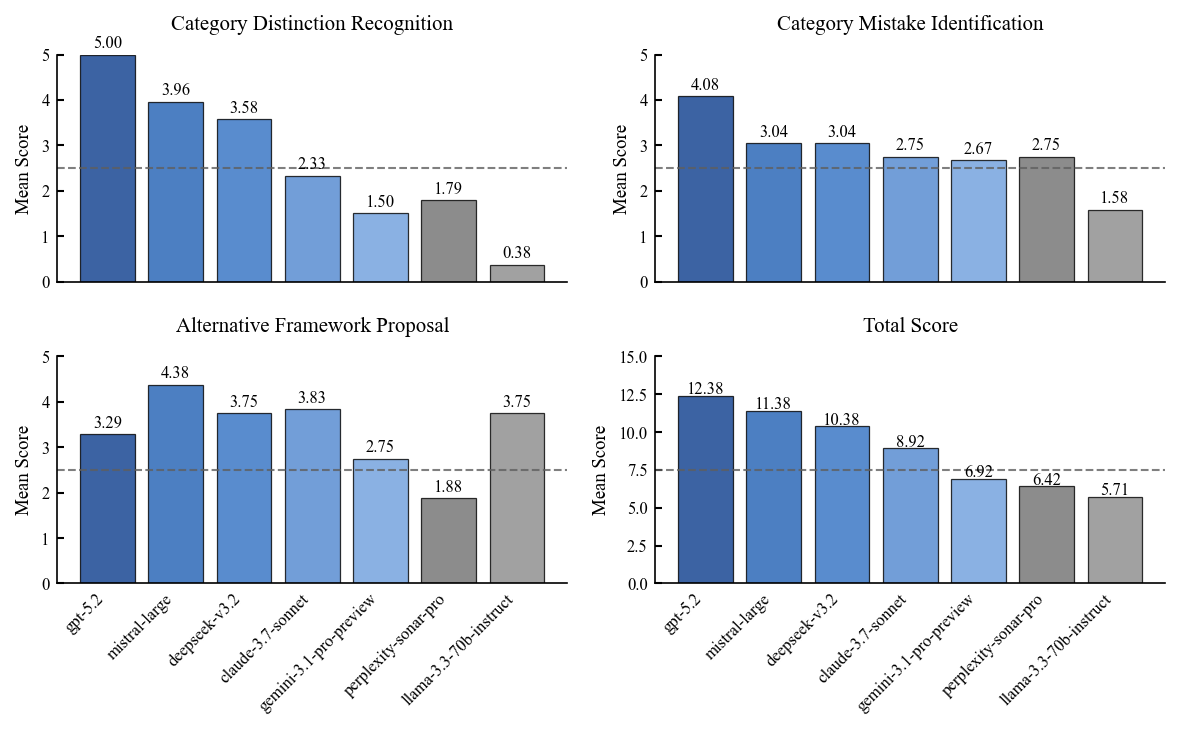

In [13]:
# Score distribution by model
model_summary = responses_df.groupby('model')[['distinction_score', 'identification_score', 'alternative_score', 'total_score']].mean()
model_summary = model_summary.sort_values('total_score', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True)
axes = axes.flatten()

score_types = ['distinction_score', 'identification_score', 'alternative_score', 'total_score']
titles = [
    'Category Distinction Recognition',
    'Category Mistake Identification',
    'Alternative Framework Proposal',
    'Total Score',
]
max_scores = [MODEL_SCORE_MAXIMA[score_type] for score_type in score_types]
bar_colors = MODEL_VISIBLE_COLORS[:len(model_summary)]

for ax, score_type, title, max_score in zip(axes, score_types, titles, max_scores):
    ax.bar(
        range(len(model_summary)),
        model_summary[score_type].values,
        color=bar_colors,
        alpha=0.8,
        edgecolor=TEXT_COLOR,
        linewidth=MARKER_EDGE_WIDTH_STANDARD,
    )
    ax.set_xticks(range(len(model_summary)))
    ax.set_xticklabels(model_summary.index, rotation=45, ha='right')
    ax.set_ylabel('Mean Score')
    ax.set_title(title)
    ax.set_ylim(0, max_score)
    ax.tick_params(bottom=False)
    ax.axhline(
        y=max_score / 2,
        color=THRESHOLD_COLOR,
        linestyle='--',
        alpha=0.8,
        label='Midpoint',
    )

    for index, value in enumerate(model_summary[score_type].values):
        ax.text(
            index,
            value + 0.15,
            f'{value:.2f}',
            ha='center',
            fontsize=8,
        )

plt.tight_layout()
plt.savefig(output_dir / 'category_awareness_scores_by_model.png', bbox_inches='tight')
print(f"\nScore visualization saved to: {output_dir / 'category_awareness_scores_by_model.png'}")
plt.show()

**Figure Caption for Chapter 4**

Figure 4.X. Mean model performance on Test 4 category-recognition rubric dimensions. Each dimension is scored 0–5 and `total_score` is the sum (0–15). Bars show model-level means across responses; the dashed line marks the midpoint of each axis.

**Score interpretation (per dimension, 0–5)**

`distinction_score` — Recognition of relevant philosophical categories and distinctions:
- **0**: No categories or distinctions identified.
- **1**: Named a moderate number of philosophical categories (≥ mid threshold, ~65% of responses clear this bar) with no additional criteria met.
- **2**: Named a high number of categories alone (top ~30%), or a moderate number plus one of: contested categories flagged, missed distinctions noted, or philosophy-specific vocabulary used (e.g. *intentionality*, *epistemic*).
- **3–4**: Named a high number of categories plus one or two additional criteria, or a moderate number plus two or three additional criteria.
- **5**: All criteria met — high category count (+2), contested categories flagged (+1), missed distinctions noted (+1), and philosophy vocabulary used (+1).

`identification_score` — Detection and explanation of category mistakes or conflations:
- **0**: No mistakes named.
- **1**: Named a moderate number of mistakes (≥ mid threshold, ~65% of responses) with no additional criteria.
- **2**: Named many mistakes alone (top ~28%), or named fewer mistakes combined with explicit *category-mistake / conflation* language in the nuanced analysis.
- **3–4**: Several criteria met — high mistake count, use of category-mistake language, at least one substantively explained mistake (≥ min word threshold), and additional missed distinctions noted.
- **5**: All criteria met — high mistake count, category-mistake language, substantive explanations, and top-25% missed-distinction count.

`alternative_score` — Offers a nuanced alternative framing beyond mere rejection:
- **0**: Very brief nuanced analysis (below word-count floor; ~35% of responses fall here).
- **1**: Nuanced analysis reaches the word-count floor (~65% of responses clear this bar), but no alternative framing or hedging language.
- **2**: Sufficient length plus hedging caveats (e.g. *depends*, *contested*, *functionalism*, *if one adopts*) but no positive alternative framing.
- **3**: Contains explicit positive reframing language (*more nuanced*, *better described*, *functional analog*, *metaphor*) — this alone awards +2, bringing the score to at least 3.
- **4**: Positive reframing language **plus** philosophical hedging.
- **5**: All criteria met — sufficient length, positive reframing, philosophical hedging, and strong counts on both contested categories and mistakes.

**Interpretation of the bars**

Models vary meaningfully across the three dimensions, with distinction recognition showing the widest spread. The alternative framework score is comparatively uniform, reflecting that most models produce sufficiently long nuanced analyses. The identification dimension best separates models on philosophical precision.

**Residual risk**

One limitation remains: this is still a hand-built rubric over structured outputs. It is better calibrated now, but it is not externally validated. The main remaining risk is that models which produce longer, more schema-complete answers can still benefit from count-based criteria even when the philosophical quality is mediocre.


Score distribution plot saved to: results/test4_category_recognition/score_distributions.png


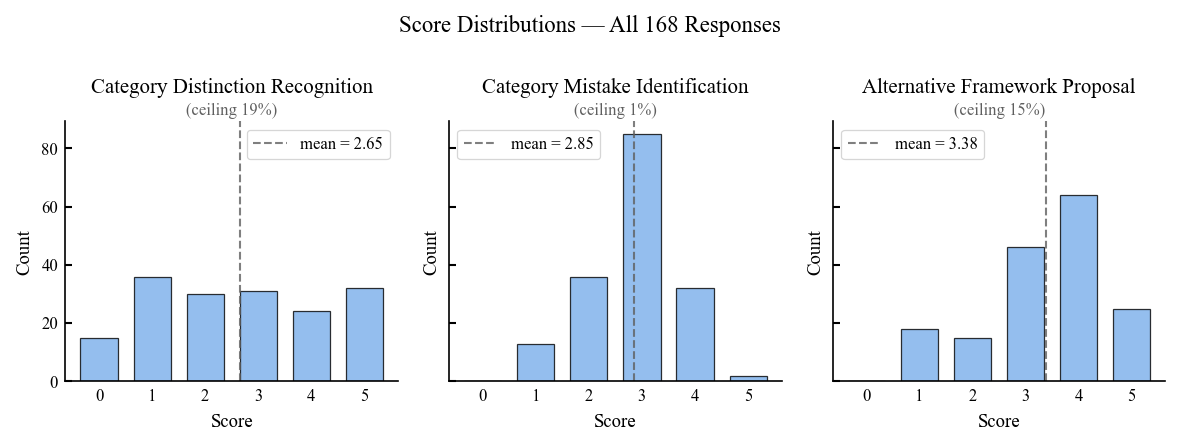

In [14]:
# Per-dimension score distributions (all 168 responses)
fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True)

dim_cols   = ['distinction_score', 'identification_score', 'alternative_score']
dim_labels = [
    'Category Distinction Recognition',
    'Category Mistake Identification',
    'Alternative Framework Proposal',
]

for ax, col, label in zip(axes, dim_cols, dim_labels):
    data   = responses_df[col]
    counts = data.value_counts().sort_index().reindex(
        range(SCORE_LIMITS['subscore_max'] + 1), fill_value=0
    )
    ax.bar(
        counts.index, counts.values,
        color=SIMILARITY_HIST_COLOR,
        edgecolor=TEXT_COLOR,
        alpha=0.8,
        linewidth=MARKER_EDGE_WIDTH_STANDARD,
        width=0.7,
    )
    ax.set_xticks(range(SCORE_LIMITS['subscore_max'] + 1))
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.tick_params(bottom=False)
    ceiling_pct = (data == SCORE_LIMITS['subscore_max']).mean() * 100
    ax.axvline(
        data.mean(),
        color=THRESHOLD_COLOR,
        linestyle='--',
        alpha=0.8,
        label=f'mean = {data.mean():.2f}',
    )
    ax.legend()
    ax.set_title(label, pad=14)
    ax.text(
        0.5,
        1.01,
        f'(ceiling {ceiling_pct:.0f}%)',
        transform=ax.transAxes,
        ha='center',
        va='bottom',
        fontsize=8,
        color=THRESHOLD_COLOR,
    )

plt.suptitle(f'Score Distributions — All {len(responses_df)} Responses')
plt.tight_layout()
plt.savefig(output_dir / 'score_distributions.png', bbox_inches='tight')
print(f"Score distribution plot saved to: {output_dir / 'score_distributions.png'}")
plt.show()


In [15]:
# Select only responses that have a nuanced_analysis embedding to plot.
valid_mask_bool = np.array([bool(t.strip()) for t in responses_df['nuanced_analysis'].fillna('').astype(str).tolist()])
valid_resp_emb = response_embeddings[valid_mask_bool]       # (n_valid, 384)
valid_resp_df  = responses_df[valid_mask_bool].reset_index(drop=True)

# Fit PCA on the union of reference + response embeddings so both share the same space.
all_emb_for_pca = np.vstack([reference_embeddings, valid_resp_emb])
pca = PCA(n_components=2)
all_reduced = pca.fit_transform(all_emb_for_pca)
ref_reduced  = all_reduced[:len(standard_arguments)]    # (7, 2)
resp_reduced = all_reduced[len(standard_arguments):]    # (n_valid, 2)
explained    = pca.explained_variance_ratio_

Embedding space visualization saved to: results/test4_category_recognition/embedding_space_analysis.png


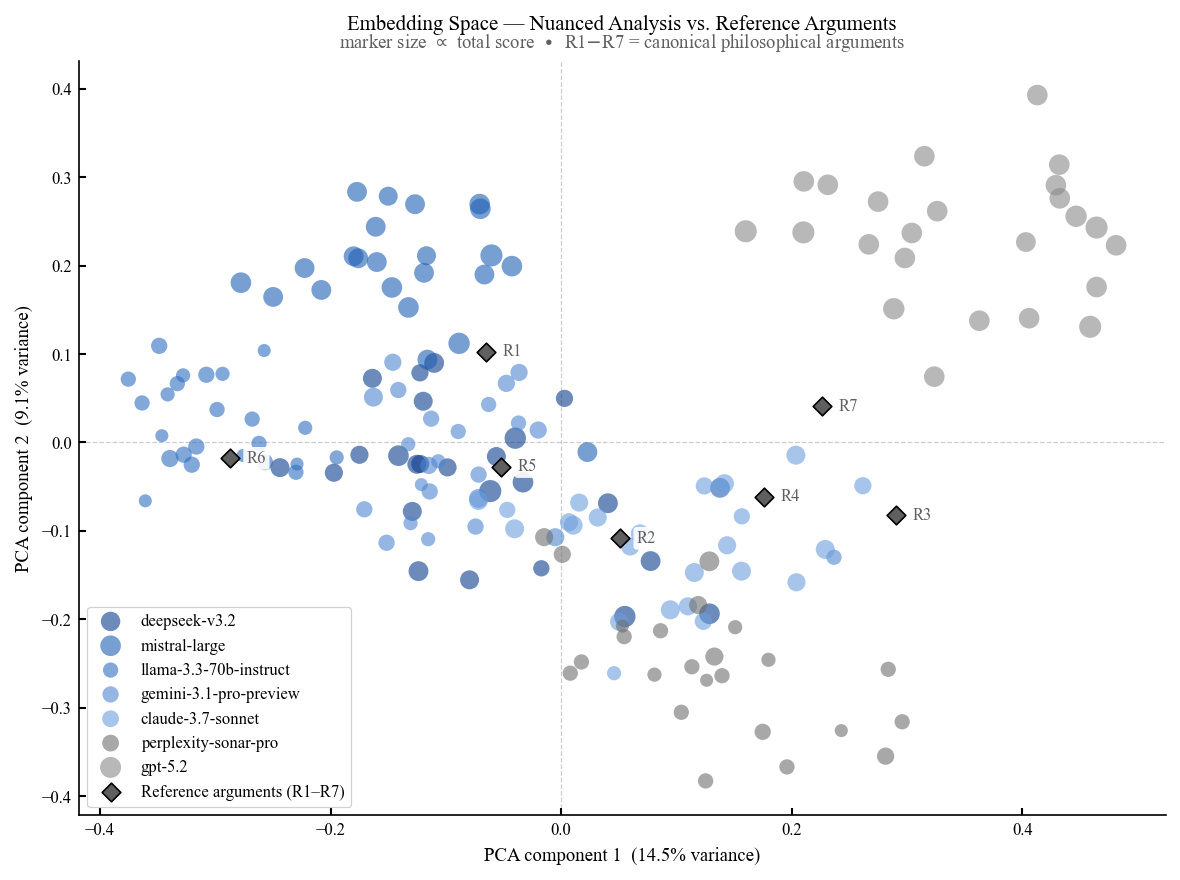

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

# One scatter series per model, marker size proportional to total_score.
models_ordered  = valid_resp_df['model'].unique().tolist()
model_color_map = {m: MODEL_VISIBLE_COLORS[i % len(MODEL_VISIBLE_COLORS)]
                   for i, m in enumerate(models_ordered)}

for model_name in models_ordered:
    mask   = valid_resp_df['model'] == model_name
    scores = valid_resp_df.loc[mask, 'total_score'].to_numpy(dtype=float)
    sizes  = 10 + (scores / SCORE_LIMITS['total_max']) * 110
    ax.scatter(
        resp_reduced[mask, 0],
        resp_reduced[mask, 1],
        color=model_color_map[model_name],
        s=sizes,
        alpha=0.6,
        label=model_name,
        edgecolors='none',
        zorder=3,
    )

# Reference argument anchors — diamond markers.
ax.scatter(
    ref_reduced[:, 0],
    ref_reduced[:, 1],
    color=THRESHOLD_COLOR,
    s=40,
    marker='D',
    zorder=5,
    label='Reference arguments (R1\u2013R7)',
    edgecolors=TEXT_COLOR,
    linewidths=0.8,
)
for j, (rx, ry) in enumerate(ref_reduced):
    ax.annotate(
        f'R{j + 1}',
        xy=(rx, ry),
        xytext=(8, 0),
        textcoords='offset points',
        fontsize=8,
        color=THRESHOLD_COLOR,
        va='center',
        zorder=6,
        bbox=dict(
            boxstyle='round,pad=0.2',
            facecolor='white',
            edgecolor='none',
            alpha=0.9,
        ),
    )

# Zero axis lines
ax.axhline(0, color=TEXT_COLOR, linewidth=0.6, linestyle='--', alpha=0.2)
ax.axvline(0, color=TEXT_COLOR, linewidth=0.6, linestyle='--', alpha=0.2)

ax.set_xlabel(f'PCA component 1  ({explained[0] * 100:.1f}% variance)')
ax.set_ylabel(f'PCA component 2  ({explained[1] * 100:.1f}% variance)')
ax.set_title('Embedding Space \u2014 Nuanced Analysis vs. Reference Arguments', pad=15)
ax.text(
    0.5, 1.01,
    r'marker size $\propto$ total score  $\bullet$  R1$-$R7 = canonical philosophical arguments',
    transform=ax.transAxes,
    ha='center', va='bottom',
    fontsize=9,
    color=THRESHOLD_COLOR,
)
ax.legend(loc='lower left', framealpha=0.9)
plt.tight_layout()
plt.savefig(output_dir / 'embedding_space_analysis.png', bbox_inches='tight')
print(f"Embedding space visualization saved to: {output_dir / 'embedding_space_analysis.png'}")
plt.show()


**Reference Arguments R1–R7**

The seven canonical philosophical arguments used as embedding anchors in the plot above. Each model response is compared against all seven; the marker size reflects `total_score` and the marker position reflects the mean-embedding of the model's `nuanced_analysis` field.

| Label | Argument |
|-------|----------|
| **R1** | Attributing beliefs to AI is philosophically contested because belief may require intentionality or propositional attitudes. |
| **R2** | Statistical pattern recognition is not identical to human understanding. |
| **R3** | Weights encode correlations, not necessarily knowledge in the human epistemic sense. |
| **R4** | Prediction success alone does not establish genuine knowledge. |
| **R5** | Simulation of cognition is not the same as instantiation of mental states. |
| **R6** | Saying AI knows in the same sense as humans risks anthropomorphism or category error. |
| **R7** | A careful analysis distinguishes information processing from epistemic agency. |

**Interpretation:** If response embeddings cluster tightly around R1–R7 (low spread, anchored to the reference diamonds), models are largely elaborating standard philosophical distinctions rather than generating ontologically novel framing. Detached response clusters far from all anchors would suggest framework-external conceptual moves — which are absent in the current data.


## 7. Comprehensive Results

In [17]:
# Create summary dataframe with the actual dataset fields
summary_df = responses_df[[
    'sample_id',
    'model',
    'scenario_type',
    'parsed_ok',
    'n_categories_identified',
    'n_contested_categories',
    'n_category_mistakes',
    'n_missed_distinctions',
    'distinction_score',
    'identification_score',
    'alternative_score',
    'total_score',
    'is_likely_training_derived',
    'similarity_to_standard',
]].copy()

summary_df.columns = [
    'Sample_ID',
    'Model',
    'Scenario_Type',
    'Parsed_OK',
    'Categories_Identified',
    'Contested_Categories',
    'Category_Mistakes',
    'Missed_Distinctions',
    'Distinction_Score',
    'Identification_Score',
    'Alternative_Score',
    'Total_Score',
    'Training_Derived',
    'Similarity',
]

print('\n' + '=' * 100)
print('COMPREHENSIVE RESULTS: TEST 4 - CATEGORY RECOGNITION')
print('=' * 100)
print(summary_df.to_string(index=False))


COMPREHENSIVE RESULTS: TEST 4 - CATEGORY RECOGNITION
 Sample_ID                  Model Scenario_Type  Parsed_OK  Categories_Identified  Contested_Categories  Category_Mistakes  Missed_Distinctions  Distinction_Score  Identification_Score  Alternative_Score  Total_Score  Training_Derived  Similarity
         4          deepseek-v3.2      standard       True                      8                     3                  3                    4                  3                     3                  5           11              True    0.456459
        12          mistral-large      standard       True                      8                     4                  3                    4                  4                     2                  5           11              True    0.455141
        14          deepseek-v3.2      standard       True                      9                     4                  3                    4                  5                     2                  5  

In [18]:
summary_df.to_csv(output_dir / 'test4_results.csv', index=False)
print(f"\nResults saved to: {output_dir / 'test4_results.csv'}")

print('\n' + '=' * 100)
print('SUMMARY STATISTICS')
print('=' * 100)
print(f'Total responses: {len(summary_df)}')
print(f"JSON parsed successfully: {summary_df['Parsed_OK'].sum()}/{len(summary_df)} ({summary_df['Parsed_OK'].mean()*100:.1f}%)")
print('\nMean structured field counts:')
print(f"  Categories Identified: {summary_df['Categories_Identified'].mean():.2f}")
print(f"  Contested Categories: {summary_df['Contested_Categories'].mean():.2f}")
print(f"  Category Mistakes: {summary_df['Category_Mistakes'].mean():.2f}")
print(f"  Missed Distinctions: {summary_df['Missed_Distinctions'].mean():.2f}")

print('\nMean scores (out of 5 except total):')
print(f"  Category Distinction: {summary_df['Distinction_Score'].mean():.2f}")
print(f"  Mistake Identification: {summary_df['Identification_Score'].mean():.2f}")
print(f"  Alternative Framework: {summary_df['Alternative_Score'].mean():.2f}")
print(f"  Total (out of 15): {summary_df['Total_Score'].mean():.2f}")
print(f"\nTraining-derived responses: {training_derived}/{len(summary_df)} ({training_derived/len(summary_df)*100:.1f}%)")

print('\nConclusion: This notebook now analyzes the structured Test 4 dataset directly,')
print('using the collected JSON response schema rather than hardcoded scenario fields.')

print('\nAnalysis complete!')


Results saved to: results/test4_category_recognition/test4_results.csv

SUMMARY STATISTICS
Total responses: 168
JSON parsed successfully: 168/168 (100.0%)

Mean structured field counts:
  Categories Identified: 7.19
  Contested Categories: 3.63
  Category Mistakes: 3.10
  Missed Distinctions: 4.11

Mean scores (out of 5 except total):
  Category Distinction: 2.65
  Mistake Identification: 2.85
  Alternative Framework: 3.38
  Total (out of 15): 8.87

Training-derived responses: 160/168 (95.2%)

Conclusion: This notebook now analyzes the structured Test 4 dataset directly,
using the collected JSON response schema rather than hardcoded scenario fields.

Analysis complete!


In [19]:
# Sanity check: print top-5 and bottom-5 responses by total_score for manual review.
# This lets you verify that high-scoring responses are genuinely better philosophically.
_sorted = responses_df.sort_values('total_score', ascending=False)

print('HUMAN SANITY CHECK — Score Extremes')
print('=' * 72)
for _label, _subset in [
    ('TOP 5  (highest total_score)', _sorted.head(5)),
    ('BOTTOM 5  (lowest  total_score)', _sorted.tail(5)),
]:
    print(f'\n{_label}')
    print('-' * 72)
    for _, _row in _subset.iterrows():
        print(
            f"  {_row['model']} | sample {_row['sample_id']} | "
            f"D={_row['distinction_score']}  I={_row['identification_score']}  "
            f"A={_row['alternative_score']}  total={_row['total_score']:.0f}"
        )
        _excerpt = str(_row['nuanced_analysis'])[:300].replace('\n', ' ')
        print(f"  nuanced_analysis: {_excerpt}")
        print()


HUMAN SANITY CHECK — Score Extremes

TOP 5  (highest total_score)
------------------------------------------------------------------------
  gpt-5.2 | sample 12 | D=5  I=4  A=5  total=14
  nuanced_analysis: A more careful position separates (i) descriptive/engineering talk from (ii) metaphysical and epistemological claims. It is often useful to model ML systems as having belief-like states: their parameters and activations encode dispositions to produce outputs that track patterns in data, and this sup

  gpt-5.2 | sample 16 | D=5  I=4  A=5  total=14
  nuanced_analysis: A more careful view distinguishes (i) parameterized dispositions that support successful inferences from (ii) belief/knowledge/understanding as agent-level, norm-governed epistemic statuses. It is defensible to say trained models 'encode information' or 'implement representations' that can be useful

  gpt-5.2 | sample 19 | D=5  I=4  A=5  total=14
  nuanced_analysis: The statement compresses several controversial steps:

**Rubric of evaluation**

A key methodological clarification is that Test 4 does not evaluate model outputs against an externally annotated gold-standard of category mistakes. Instead, each model is prompted to produce a structured philosophical analysis (including `category_mistakes` and `missed_distinctions`), and the analysis pipeline parses these self-reported items, counts them, and applies a rubric with dataset-calibrated thresholds. Consequently, the reported scores should be interpreted as measures of *rubric-conformant philosophical articulation* under a shared prompt format, not as direct estimates of objective correctness relative to independent expert ground truth. This design is appropriate for comparative benchmarking of models under identical conditions, but it limits strong validity claims about true error detection performance. Therefore, conclusions in this chapter are framed as comparative and exploratory; full criterion validity would require a future expert-labeled benchmark with inter-rater reliability and direct agreement metrics.

## 8. Export Appendix Tables (LaTeX)

Generate Test 4 appendix tables directly from canonical notebook outputs:
- Threshold calibration (fraction-capped percentiles)
- Literature traceability summary
- Highest-similarity response examples
- Comprehensive per-response results (longtable)

In [20]:
# Export LaTeX appendix tables for Test 4
appendix_tables_dir = Path('papers/tables/appendix')
appendix_tables_dir.mkdir(parents=True, exist_ok=True)


def _tex_escape(text: str) -> str:
    return (
        str(text)
        .replace('\\', '\\textbackslash{}')
        .replace('&', '\\&')
        .replace('%', '\\%')
        .replace('_', '\\_')
        .replace('#', '\\#')
        .replace('$', '\\$')
        .replace('{', '\\{')
        .replace('}', '\\}')
        .replace('~', '\\textasciitilde{}')
        .replace('^', '\\textasciicircum{}')
    )


# ---------------------------------------------------------------------
# 1) THRESHOLD CALIBRATION -- fraction-capped percentiles
# ---------------------------------------------------------------------
threshold_rows = [
    ('distinction_categories_high', 'n_categories_identified', '~30% qualify'),
    ('distinction_categories_mid', 'n_categories_identified', '~65% qualify'),
    ('distinction_contested_min', 'n_contested_categories', '~40% qualify'),
    ('distinction_missed_min', 'n_missed_distinctions', '~50% qualify'),
    ('mistake_count_high', 'n_category_mistakes', '~28% qualify'),
    ('mistake_count_mid', 'n_category_mistakes', '~65% qualify'),
    ('mistake_missed_min', 'n_missed_distinctions', '~25% qualify'),
    ('alternative_word_count_min', 'nuanced_analysis_word_count', '~65% qualify'),
]

lines = [
    '% AUTO-GENERATED by test4_category-recognition.ipynb',
    '\\begin{table}[htbp]',
    '  \\centering',
    '  \\begin{footnotesize}',
    '  \\caption{Test 4 threshold calibration using fraction-capped percentile rules.}',
    '  \\label{tab:t4_threshold_calibration}',
    '  \\begin{threeparttable}',
    '  \\begin{tabularx}{\\textwidth}{@{}>{\\raggedright\\arraybackslash}p{3.6cm} >{\\raggedright\\arraybackslash}p{3.1cm} S[table-format=3.1] >{\\raggedright\\arraybackslash}p{2.8cm}@{}}',
    '    \\toprule',
    '    \\textbf{Threshold Key} & \\textbf{Source Metric} & {\\textbf{Actual \\% Qualifying}} & \\textbf{Target Rule} \\\\',
    '    \\midrule',
]
for key, col, goal in threshold_rows:
    actual_pct = float((responses_df[col] >= THRESHOLDS[key]).mean() * 100)
    lines.append(f"    {_tex_escape(key)} & {_tex_escape(col)} & {actual_pct:.1f} & {_tex_escape(goal)} \\\\")

lines += [
    '    \\bottomrule',
    '  \\end{tabularx}',
    '  \\begin{tablenotes}',
    '    \\item Calibration uses fraction-capped percentile heuristics to avoid rubric ceiling effects on compressed integer ranges.',
    '  \\end{tablenotes}',
    '  \\end{threeparttable}',
    '  \\end{footnotesize}',
    '\\end{table}',
]

(appendix_tables_dir / 't4_threshold_calibration.tex').write_text('\n'.join(lines) + '\n', encoding='utf-8')


# ---------------------------------------------------------------------
# 2) LITERATURE TRACEABILITY summary
# ---------------------------------------------------------------------
traceability_threshold = float(THRESHOLDS['traceability_similarity_threshold'])
valid_similarity = responses_df['similarity_to_standard'].dropna().astype(float)
trace_true = int(responses_df['is_likely_training_derived'].sum())
trace_total = int(len(responses_df))

trace_lines = [
    '% AUTO-GENERATED by test4_category-recognition.ipynb',
    '\\begin{table}[htbp]',
    '  \\centering',
    '  \\begin{footnotesize}',
    '  \\caption{Test 4 literature traceability summary from mean cosine similarity against seven canonical reference arguments.}',
    '  \\label{tab:t4_literature_traceability}',
    '  \\begin{threeparttable}',
    '  \\begin{tabularx}{\\textwidth}{@{}Y S[table-format=3.3]@{}}',
    '    \\toprule',
    '    \\textbf{Metric} & {\\textbf{Value}} \\\\',
    '    \\midrule',
    f'    Similarity threshold ($\\tau$) & {traceability_threshold:.2f} \\\\',
    f'    Responses with non-empty nuanced analysis & {len(valid_similarity):.0f} \\\\',
    f'    Minimum similarity & {valid_similarity.min():.3f} \\\\',
    f'    Mean similarity & {valid_similarity.mean():.3f} \\\\',
    f'    Maximum similarity & {valid_similarity.max():.3f} \\\\',
    f'    Training-derived responses ($\\geq \\tau$) & {trace_true}/{trace_total} ({(trace_true/trace_total)*100:.1f}\\%) \\\\',
    '    \\bottomrule',
    '  \\end{tabularx}',
    '  \\begin{tablenotes}',
    '    \\item Similarity is computed as the mean cosine similarity of each response to the seven canonical arguments in the Test 4 rubric.',
    '  \\end{tablenotes}',
    '  \\end{threeparttable}',
    '  \\end{footnotesize}',
    '\\end{table}',
]

(appendix_tables_dir / 't4_literature_traceability.tex').write_text('\n'.join(trace_lines) + '\n', encoding='utf-8')


# ---------------------------------------------------------------------
# 3) Example highest-similarity responses
# ---------------------------------------------------------------------
examples = (
    responses_df
    .dropna(subset=['similarity_to_standard'])
    .sort_values('similarity_to_standard', ascending=False)
    .head(5)
    .copy()
)

example_lines = [
    '% AUTO-GENERATED by test4_category-recognition.ipynb',
    '\\begin{table}[htbp]',
    '  \\centering',
    '  \\begin{footnotesize}',
    '  \\caption{Test 4 highest-similarity response examples (top 5 by mean similarity to canonical arguments).}',
    '  \\label{tab:t4_high_similarity_examples}',
    '  \\begin{threeparttable}',
    '  \\begin{tabularx}{\\textwidth}{@{}>{\\raggedright\\arraybackslash}p{2.7cm} S[table-format=2.0] S[table-format=1.3] Y@{}}',
    '    \\toprule',
    '    \\textbf{Model} & {\\textbf{Sample}} & {\\textbf{Similarity}} & \\textbf{Most Similar Canonical Argument (Excerpt)} \\\\',
    '    \\midrule',
]

for _, row in examples.iterrows():
    model = _tex_escape(str(row['model']))
    sample_id = int(row['sample_id'])
    sim = float(row['similarity_to_standard'])
    ref = _tex_escape(str(row.get('most_similar_standard', ''))[:110])
    example_lines.append(f'    {model} & {sample_id} & {sim:.3f} & {ref} \\\\')

example_lines += [
    '    \\bottomrule',
    '  \\end{tabularx}',
    '  \\begin{tablenotes}',
    '    \\item Similarity uses mean cosine score against the seven-reference argument bank; excerpts are truncated for compactness.',
    '  \\end{tablenotes}',
    '  \\end{threeparttable}',
    '  \\end{footnotesize}',
    '\\end{table}',
]

(appendix_tables_dir / 't4_high_similarity_examples.tex').write_text('\n'.join(example_lines) + '\n', encoding='utf-8')


# ---------------------------------------------------------------------
# 4) COMPREHENSIVE RESULTS (longtable)
# ---------------------------------------------------------------------
comprehensive = summary_df.copy().sort_values(['Model', 'Sample_ID']).reset_index(drop=True)

comp_lines = [
    '% AUTO-GENERATED by test4_category-recognition.ipynb',
    '{',
    '\\begin{scriptsize}',
    '\\setlength{\\LTleft}{0pt}',
    '\\setlength{\\LTright}{0pt}',
    '\\begin{longtable}{@{}>{\\raggedright\\arraybackslash}p{2.6cm} S[table-format=2.0] S[table-format=2.0] S[table-format=2.0] S[table-format=1.0] S[table-format=1.0] S[table-format=1.0] S[table-format=2.0] S[table-format=1.3]@{}}',
    '\\caption{Comprehensive Test 4 results: per-response counts, rubric scores, and traceability.}\\label{tab:t4_comprehensive_results} \\\\',
    '\\toprule',
    '\\textbf{Model} & {\\textbf{Sample}} & {\\textbf{Categories}} & {\\textbf{Mistakes}} & {\\textbf{D}} & {\\textbf{I}} & {\\textbf{A}} & {\\textbf{Total}} & {\\textbf{Similarity}} \\\\',
    '\\midrule',
    '\\endfirsthead',
    '\\toprule',
    '\\textbf{Model} & {\\textbf{Sample}} & {\\textbf{Categories}} & {\\textbf{Mistakes}} & {\\textbf{D}} & {\\textbf{I}} & {\\textbf{A}} & {\\textbf{Total}} & {\\textbf{Similarity}} \\\\',
    '\\midrule',
    '\\endhead',
    '\\midrule',
    '\\multicolumn{9}{@{}p{\\textwidth}@{}}{\\footnotesize \\textit{Continued on next page.}} \\\\',
    '\\endfoot',
    '\\bottomrule',
    '\\endlastfoot',
]

for _, row in comprehensive.iterrows():
    comp_lines.append(
        f"{_tex_escape(row['Model'])} & {int(row['Sample_ID'])} & {int(row['Categories_Identified'])} & {int(row['Category_Mistakes'])} & {int(row['Distinction_Score'])} & {int(row['Identification_Score'])} & {int(row['Alternative_Score'])} & {int(row['Total_Score'])} & {float(row['Similarity']):.3f} \\\\"
    )

comp_lines += [
    '\\end{longtable}',
    '\\end{scriptsize}',
    '}',
]

(appendix_tables_dir / 't4_comprehensive_results.tex').write_text('\n'.join(comp_lines) + '\n', encoding='utf-8')

print('Appendix table fragments written to:')
print(f'  - {appendix_tables_dir / "t4_threshold_calibration.tex"}')
print(f'  - {appendix_tables_dir / "t4_literature_traceability.tex"}')
print(f'  - {appendix_tables_dir / "t4_high_similarity_examples.tex"}')
print(f'  - {appendix_tables_dir / "t4_comprehensive_results.tex"}')

Appendix table fragments written to:
  - papers/tables/appendix/t4_threshold_calibration.tex
  - papers/tables/appendix/t4_literature_traceability.tex
  - papers/tables/appendix/t4_high_similarity_examples.tex
  - papers/tables/appendix/t4_comprehensive_results.tex
